In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.config import DATA_PATH, EXPORT_DIR, apply_display_settings
from src.data_loader import load_data
from src.profiling import run_profiling, key_findings
from src.features import build_features, feature_preview, feature_health
from src.commercial import run_commercial
from src.text_signals import run_text_signals
from src.freshness import run_freshness
from src.models.segmentation import run_segmentation, segmentation_readout
from src.models.anomaly import run_anomaly, anomaly_readout
from src.models.propensity import run_propensity
from src.benchmark import run_benchmark
from src.opportunity import run_opportunity
from src.summary import build_summary
from src.export import export_all
from src.dashboard import launch_dashboard
from src.plotting import (
    plot_visual_audit, plot_price_vs_rating, plot_discount_penetration,
    plot_brand_engagement, plot_text_signals, plot_benchmark,
    plot_freshness, plot_opportunity_map,
)

apply_display_settings()
print("Setup OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup OK


In [8]:
df = load_data(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

tables = run_profiling(df)
display(Markdown("### Column audit"))
display(tables["column_audit"])
display(Markdown("### Numeric profile"))
display(tables["numeric_profile"])
display(Markdown("### Audit notes"))
display(tables["audit_notes"])
display(Markdown("### Missing rating % by source"))
display(tables["rating_missing_by_source"])
display(Markdown(key_findings(df)))

Shape: 1,000 rows x 21 columns


,product_id,external_id,title,brand,category,subcategory,url,source,price_current,price_original,currency,discount_pct,has_discount,rating_score,reviews_count,availability,description,images_count,first_image,tags,scraped_at
0,9efc81ac-b34e-487a-b7a1-6fe9c9d7920b,9749998221059,Huawei Tablet Pro,Huawei,Electronics,NaN,https://www.amazon.com/product/huawei-tablet-pro-1,amazon,1487.49,NaN,USD,NaN,False,4.8,177,in_stock,Crafted with attention to detail and backed by comprehensive warranty coverage.,1,https://cdn.amazon.example/img/9749998221059.jpg,amazon|electronics,2026-03-21 05:42:24.094706
1,6c26ff34-72d3-45d8-aa01-71e58253e3c6,8979986990555,Adidas Portable Hoodie Plus,Adidas,Fashion,NaN,https://www.amazon.com/product/adidas-portable-hoodie-plus-2,amazon,1125.26,1575.36,USD,28.6,True,3.7,665,out_of_stock,A versatile product suitable for a wide range of applications and users.,1,https://cdn.amazon.example/img/8979986990555.jpg,amazon|fashion,2026-03-27 11:23:36.862451
2,b271d64f-790b-4561-af51-5ff5d7b0a132,9473792172229,Calvin Klein Sneakers Pro,Calvin,Fashion,NaN,https://www.amazon.com/product/calvin-klein-sneakers-pro-3,amazon,1357.13,NaN,USD,NaN,False,3.9,379,out_of_stock,Thoughtfully designed to deliver value without cutting corners on key features.,1,https://cdn.amazon.example/img/9473792172229.jpg,amazon|fashion,2026-03-24 17:44:49.598673
3,f8beb32f-30b3-4128-b813-820780d2a67c,390919824546,Nestle Lightweight Dried Fruits Pro,Nestle,Food,NaN,https://www.amazon.com/product/nestle-lightweight-dried-fruits-pro-4,amazon,1553.58,1724.47,USD,9.9,True,4.1,4,limited,A trusted choice for professionals and enthusiasts alike.,1,https://cdn.amazon.example/img/0390919824546.jpg,amazon|food,2026-03-16 03:50:09.844085
4,bbbb408c-5460-457c-b4ca-55f0af33ee29,3016548993474,Braun Portable Vacuum Cleaner 2024,Braun,Home,NaN,https://www.amazon.com/product/braun-portable-vacuum-cleaner-2024-5,amazon,509.81,NaN,USD,NaN,False,4.5,88,in_stock,Combining modern aesthetics with functional engineering for discerning users.,1,https://cdn.amazon.example/img/3016548993474.jpg,amazon|home,2026-03-14 18:13:11.642972


### Column audit

,column,role,missing_values,missing_pct,unique_values,quality_flag
0,subcategory,Numeric,1000,100.0,0,Drop or ignore: fully missing
1,price_original,Numeric,716,71.6,284,Needs careful treatment
2,discount_pct,Numeric,716,71.6,41,Needs careful treatment
3,rating_score,Numeric,204,20.4,26,Analysis ready
4,product_id,Identifier / high-cardinality,0,0.0,1000,Use for identity only
5,external_id,Identifier / high-cardinality,0,0.0,1000,Use for identity only
6,url,Identifier / high-cardinality,0,0.0,1000,Use for identity only
7,first_image,Identifier / high-cardinality,0,0.0,1000,Use for identity only
8,scraped_at,Identifier / high-cardinality,0,0.0,1000,Probably not useful for aggregation
9,price_current,Identifier / high-cardinality,0,0.0,997,Probably not useful for aggregation


### Numeric profile

...

### Audit notes

,check,value
0,Duplicate product_id,0
1,Duplicate external_id,0
2,Fully missing columns,subcategory
3,Constant columns,"subcategory, images_count"
4,Currencies present,"AED, EGP, USD"
5,Sources present,"aliexpress, amazon, ebay, jumia, noon"


### Missing rating % by source

,source,missing_rating_pct
0,aliexpress,23.5
1,jumia,23.5
2,ebay,18.5
3,noon,18.5
4,amazon,18.0


- Fully missing columns (ignore karo): `subcategory`
- Constant columns (koi analytical value nahi): `images_count`
- `price_original` aur `discount_pct` non-discounted products mein structurally missing hain, random nulls nahi.
- Price comparison currency ke andar karo. Currencies: AED, EGP, USD.
- `product_id`, `external_id`, `url`, `first_image` sirf record trace karne ke liye hain, aggregation ke liye nahi.

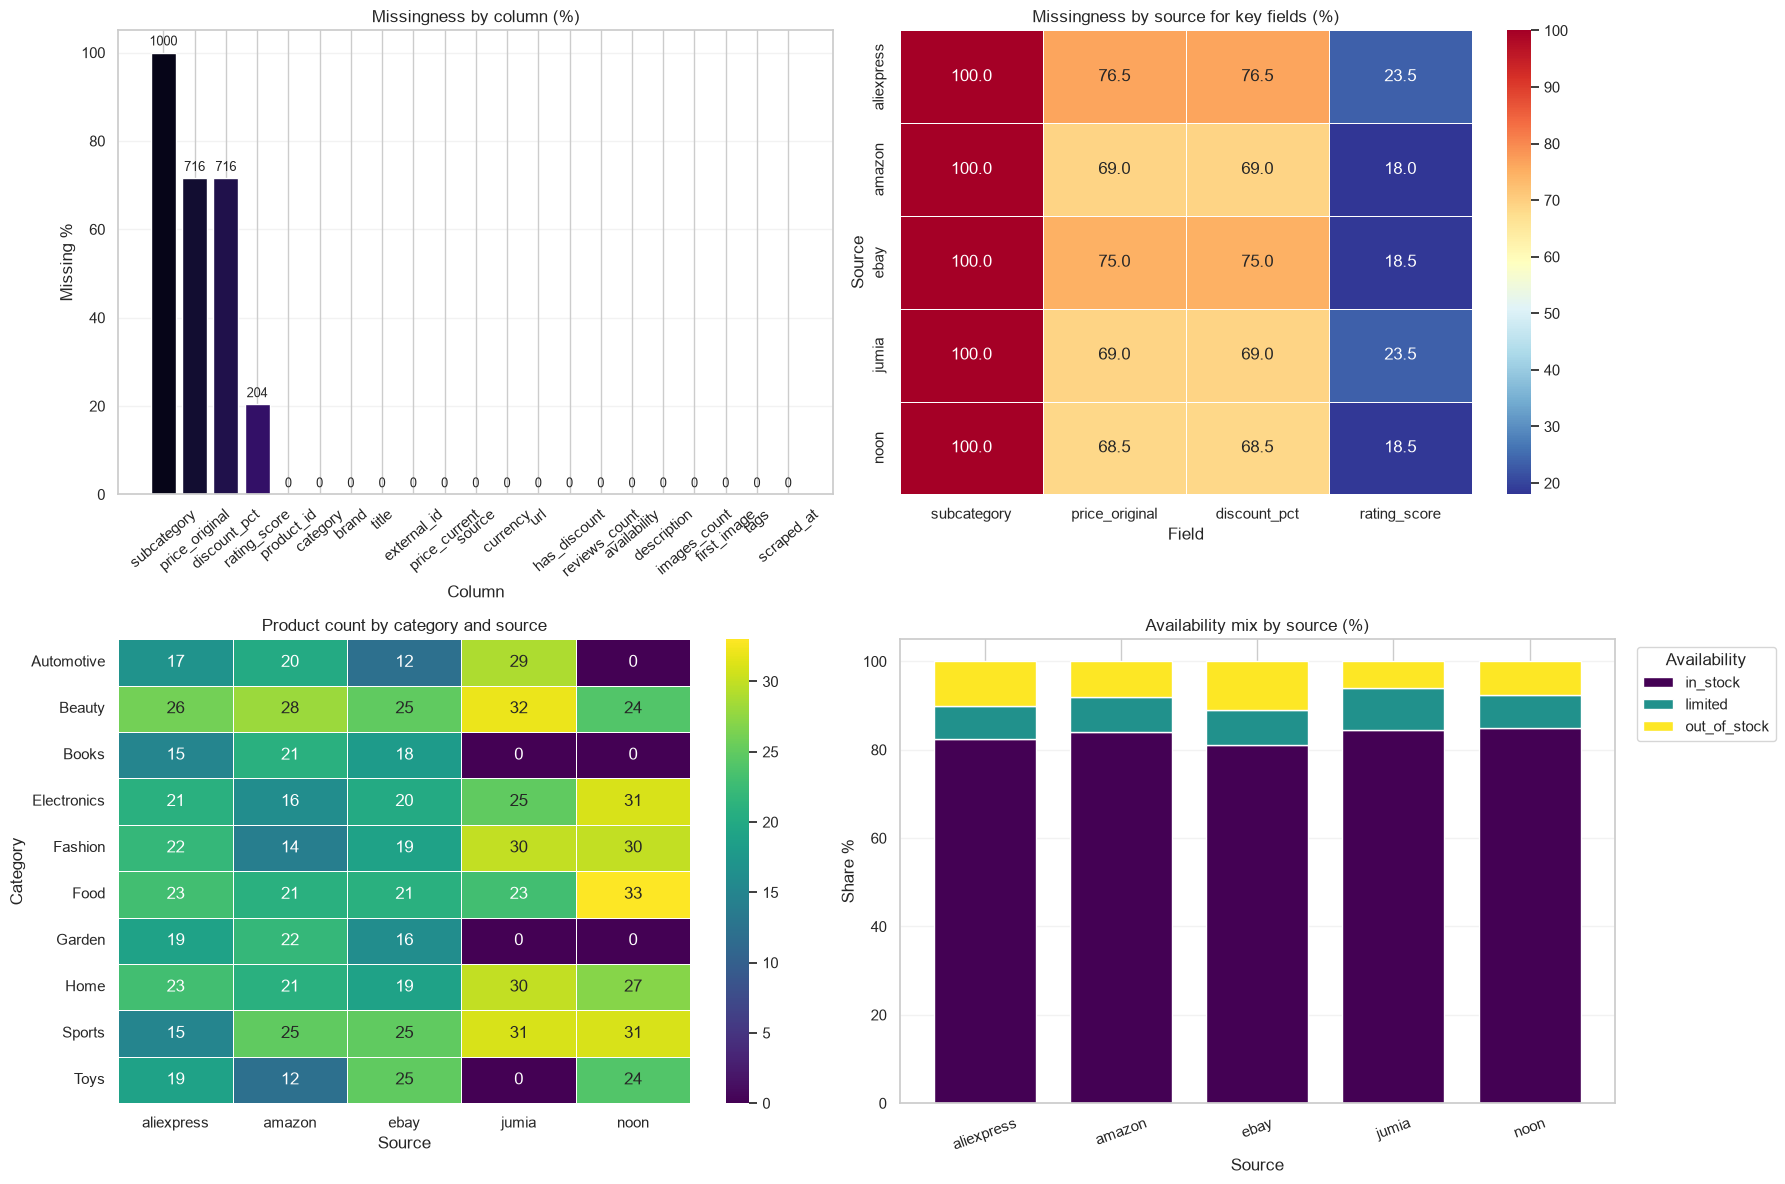

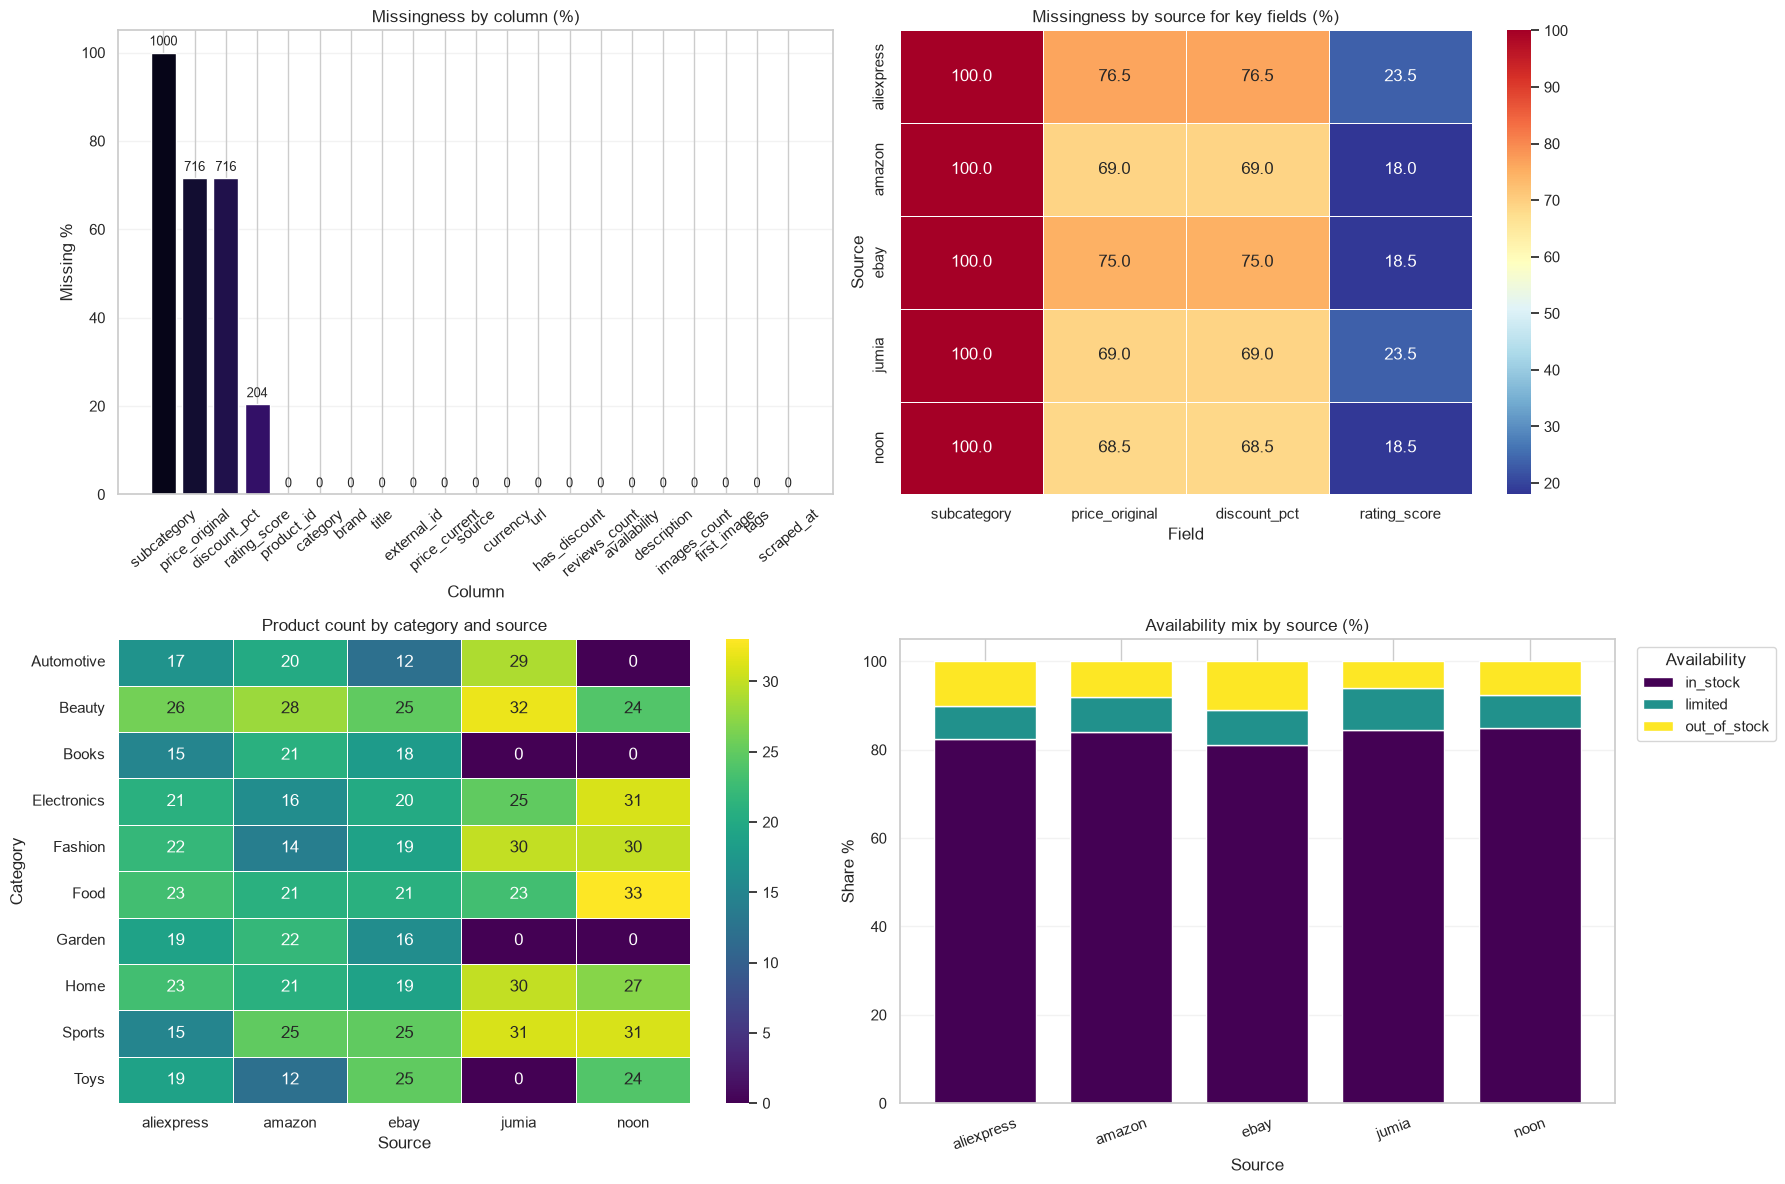

In [6]:
plot_visual_audit(tables)

In [7]:
eda_df = build_features(df)
display(feature_preview(eda_df))
display(feature_health(eda_df))

,title,brand,source,currency,price_current,price_original_filled,discount_pct_filled,has_discount,discount_amount,rating_score_imputed,rating_missing_flag,reviews_count,price_tier_within_currency,discount_depth,engagement_score
0,Huawei Tablet Pro,Huawei,amazon,USD,1487.49,1487.49,0.0,0,0.00,4.8,0,177,Premium,No discount,24.872561
1,Adidas Portable Hoodie Plus,Adidas,amazon,USD,1125.26,1575.36,28.6,1,450.10,3.7,0,665,Premium,High,24.054772
2,Calvin Klein Sneakers Pro,Calvin,amazon,USD,1357.13,1357.13,0.0,0,0.00,3.9,0,379,Premium,No discount,23.166668
3,Nestle Lightweight Dried Fruits Pro,Nestle,amazon,USD,1553.58,1724.47,9.9,1,170.89,4.1,0,4,Premium,Low,6.598695
4,Braun Portable Vacuum Cleaner 2024,Braun,amazon,USD,509.81,509.81,0.0,0,0.00,4.5,0,88,Mid-range,No discount,20.198864
5,Charlotte Tilbury Nail Polish,Charlotte,amazon,USD,1016.25,1158.52,12.3,1,142.27,3.3,0,8,Premium,Medium,7.250841
6,Shell Tool Kit v2,Shell,amazon,USD,2108.26,2108.26,0.0,0,0.00,3.3,0,71,Luxury,No discount,14.112998
7,Reebok Backpack Pro,Reebok,amazon,USD,1164.15,1594.89,27.0,1,430.74,3.8,1,0,Premium,High,0.000000
8,Husqvarna Compact Plant Pot Pro,Husqvarna,amazon,USD,1598.19,2253.45,29.1,1,655.26,3.8,1,0,Premium,High,0.000000
9,Gardena Classic Watering Can v2,Gardena,amazon,USD,1723.02,1723.02,0.0,0,0.00,4.5,0,683,Premium,No discount,29.375811


,feature,missing_pct
0,discount_pct_filled,0.0
1,has_discount,0.0
2,discount_amount,0.0
3,rating_score_imputed,0.0
4,price_tier_within_currency,0.0
5,discount_depth,0.0
6,engagement_score,0.0


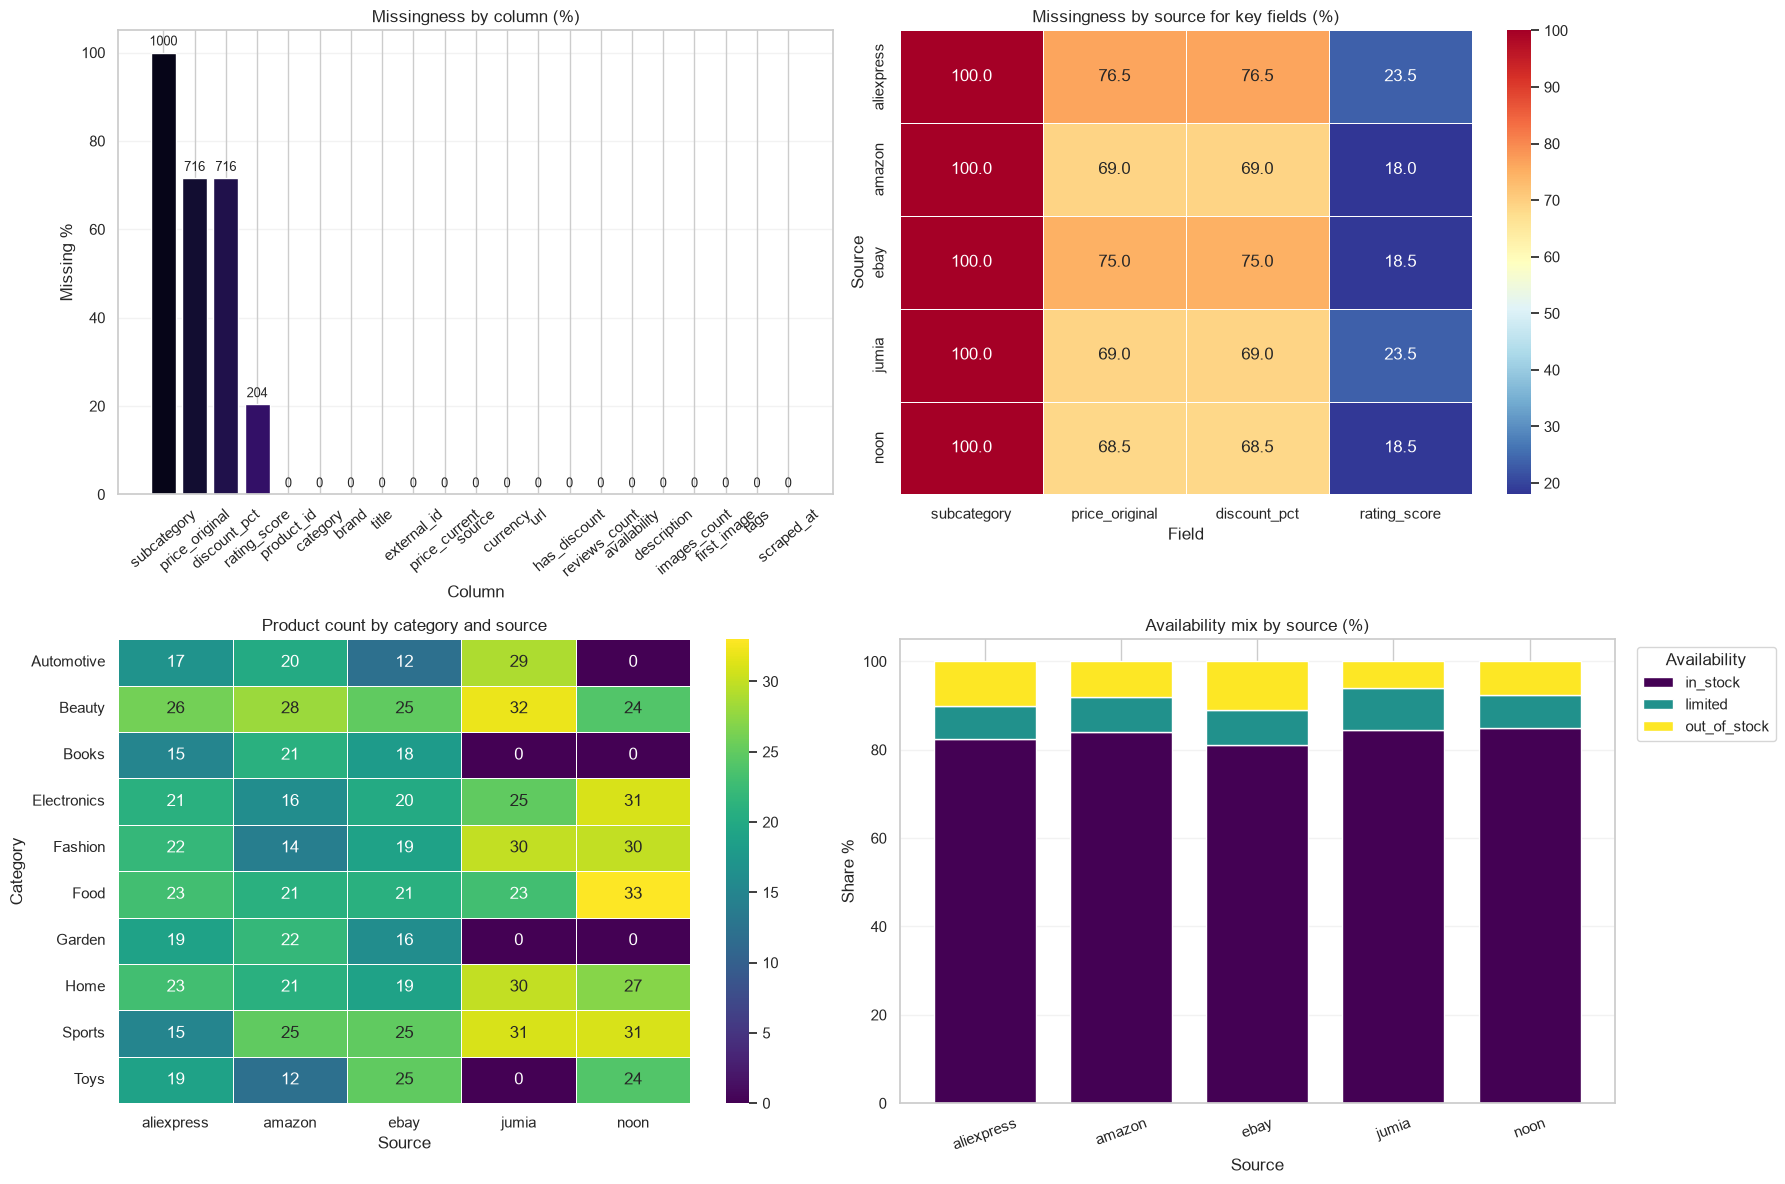

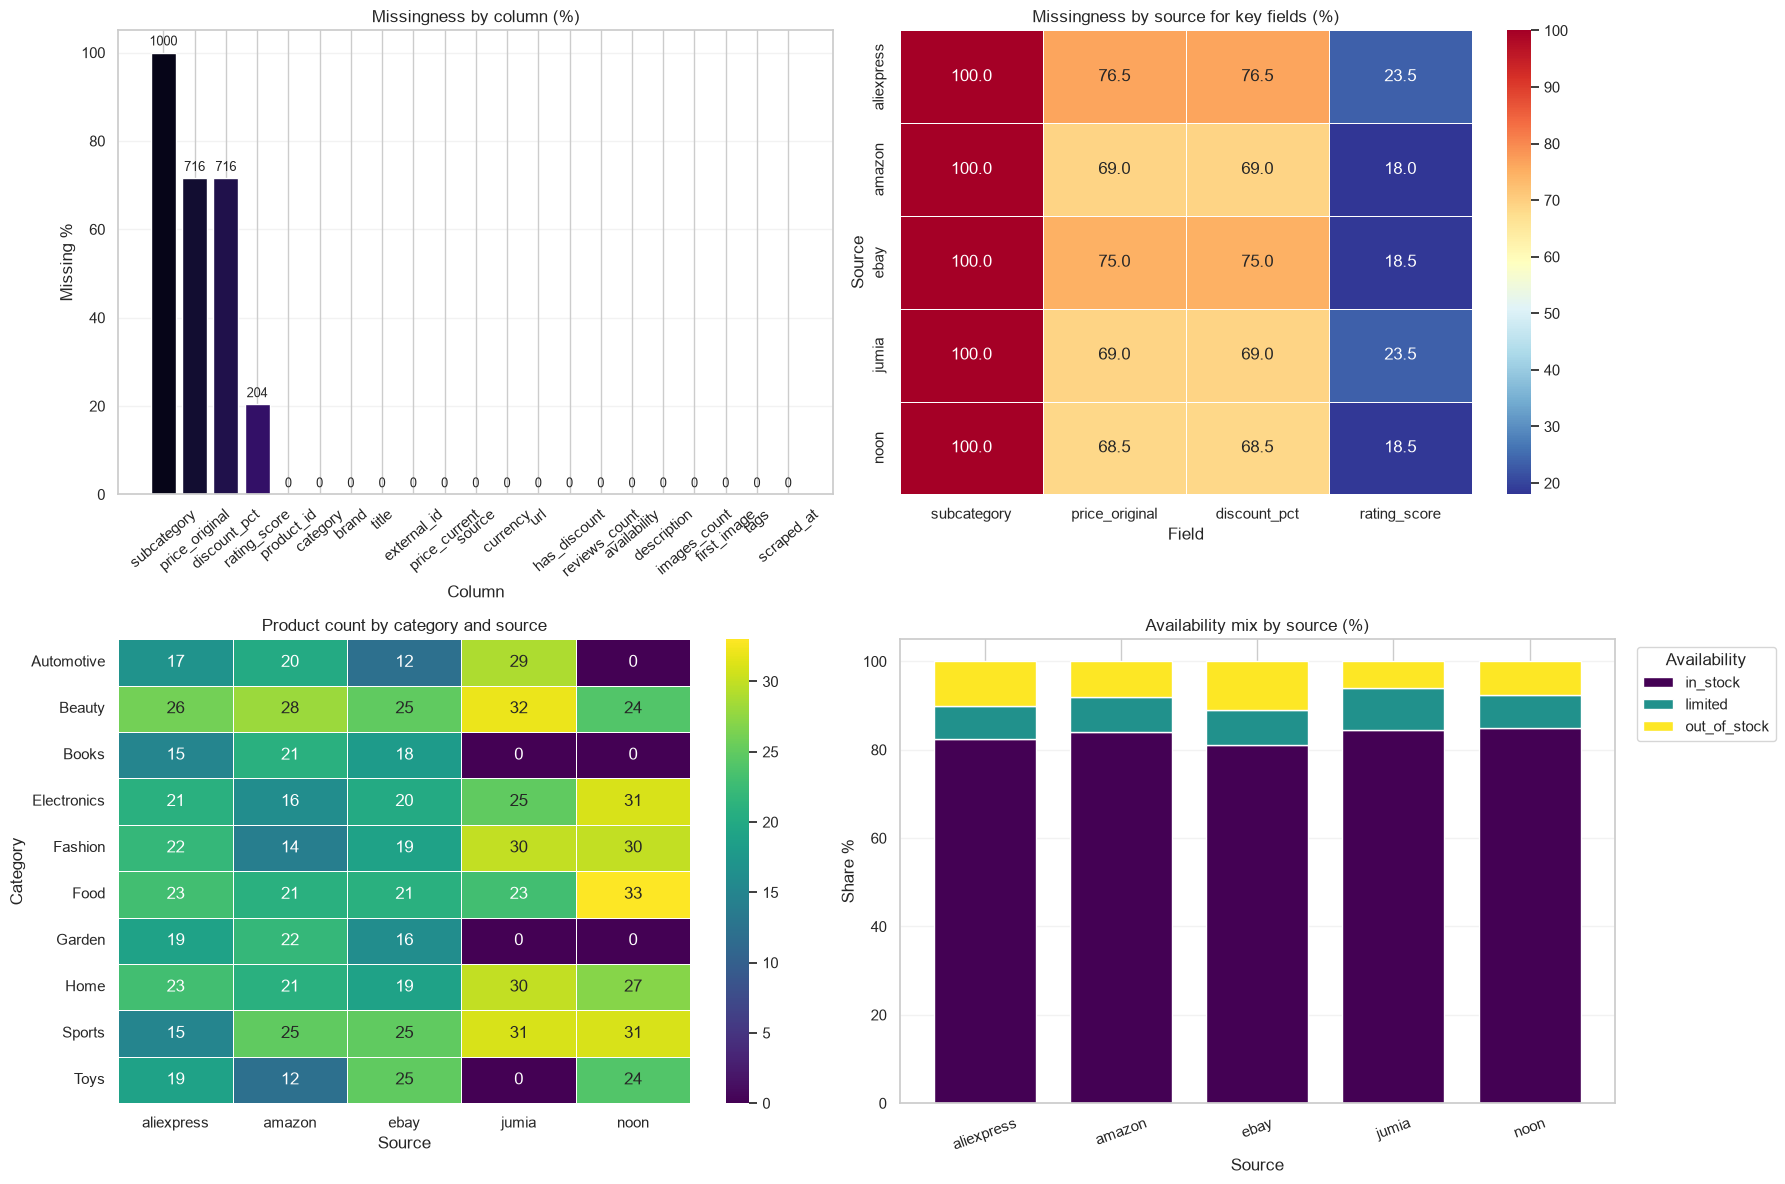

In [11]:
plot_visual_audit(tables)

In [12]:
eda_df = build_features(df)
display(feature_preview(eda_df))
display(feature_health(eda_df))

,title,brand,source,currency,price_current,price_original_filled,discount_pct_filled,has_discount,discount_amount,rating_score_imputed,rating_missing_flag,reviews_count,price_tier_within_currency,discount_depth,engagement_score
0,Huawei Tablet Pro,Huawei,amazon,USD,1487.49,1487.49,0.0,0,0.00,4.8,0,177,Premium,No discount,24.872561
1,Adidas Portable Hoodie Plus,Adidas,amazon,USD,1125.26,1575.36,28.6,1,450.10,3.7,0,665,Premium,High,24.054772
2,Calvin Klein Sneakers Pro,Calvin,amazon,USD,1357.13,1357.13,0.0,0,0.00,3.9,0,379,Premium,No discount,23.166668
3,Nestle Lightweight Dried Fruits Pro,Nestle,amazon,USD,1553.58,1724.47,9.9,1,170.89,4.1,0,4,Premium,Low,6.598695
4,Braun Portable Vacuum Cleaner 2024,Braun,amazon,USD,509.81,509.81,0.0,0,0.00,4.5,0,88,Mid-range,No discount,20.198864
5,Charlotte Tilbury Nail Polish,Charlotte,amazon,USD,1016.25,1158.52,12.3,1,142.27,3.3,0,8,Premium,Medium,7.250841
6,Shell Tool Kit v2,Shell,amazon,USD,2108.26,2108.26,0.0,0,0.00,3.3,0,71,Luxury,No discount,14.112998
7,Reebok Backpack Pro,Reebok,amazon,USD,1164.15,1594.89,27.0,1,430.74,3.8,1,0,Premium,High,0.000000
8,Husqvarna Compact Plant Pot Pro,Husqvarna,amazon,USD,1598.19,2253.45,29.1,1,655.26,3.8,1,0,Premium,High,0.000000
9,Gardena Classic Watering Can v2,Gardena,amazon,USD,1723.02,1723.02,0.0,0,0.00,4.5,0,683,Premium,No discount,29.375811


,feature,missing_pct
0,discount_pct_filled,0.0
1,has_discount,0.0
2,discount_amount,0.0
3,rating_score_imputed,0.0
4,price_tier_within_currency,0.0
5,discount_depth,0.0
6,engagement_score,0.0


### Source-level commercial summary

,source,currency,products,median_price,avg_rating,avg_reviews,discounted_share,avg_discount,in_stock_share
0,noon,AED,200,3893.20,3.78,273.71,31.5,5.70,85.0
1,amazon,USD,200,1317.08,3.83,257.42,31.0,5.55,84.0
2,jumia,EGP,200,23715.24,3.72,242.13,31.0,6.11,84.5
3,ebay,USD,200,1617.62,3.72,273.48,25.0,5.18,81.0
4,aliexpress,USD,200,229.82,3.79,280.12,23.5,4.36,82.5


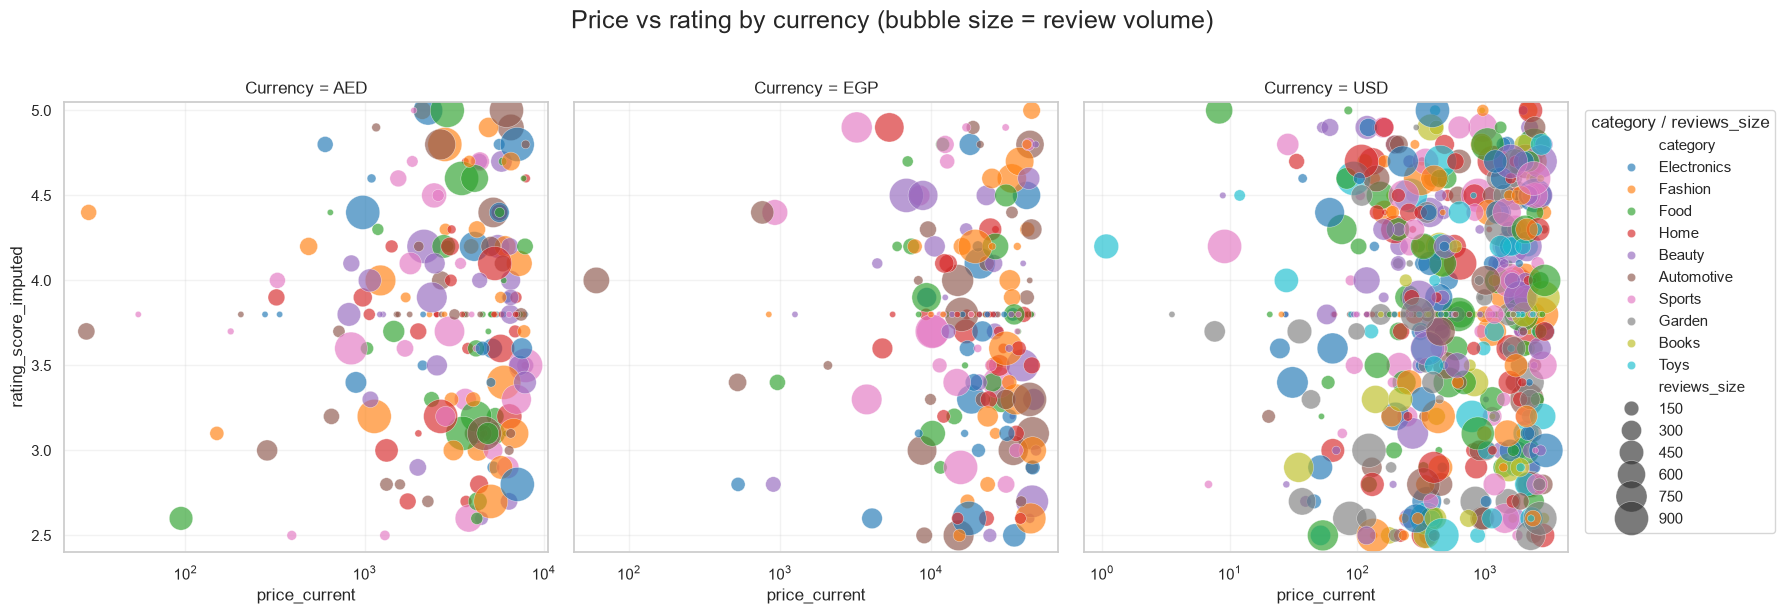

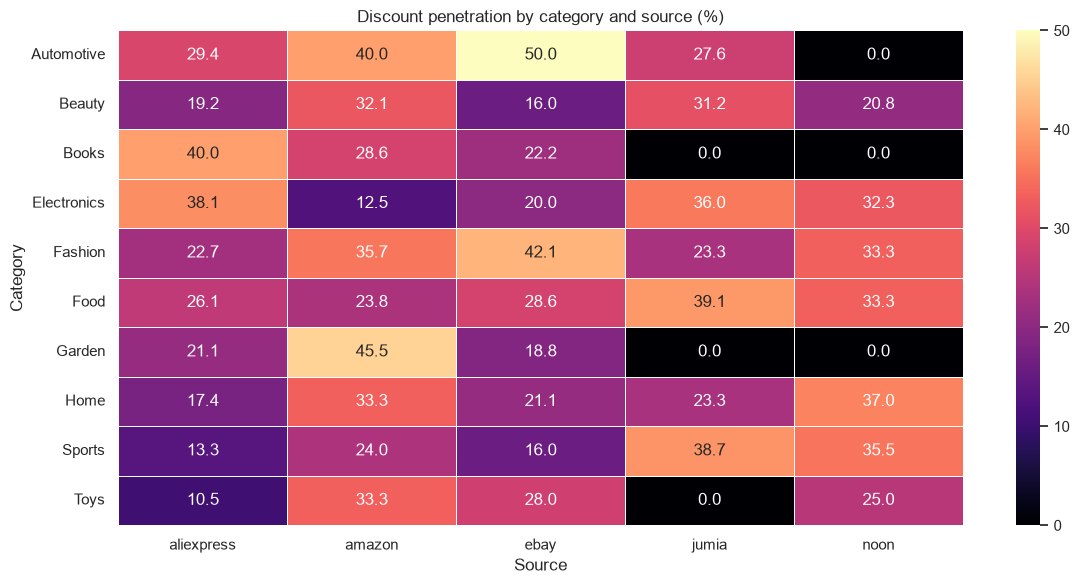

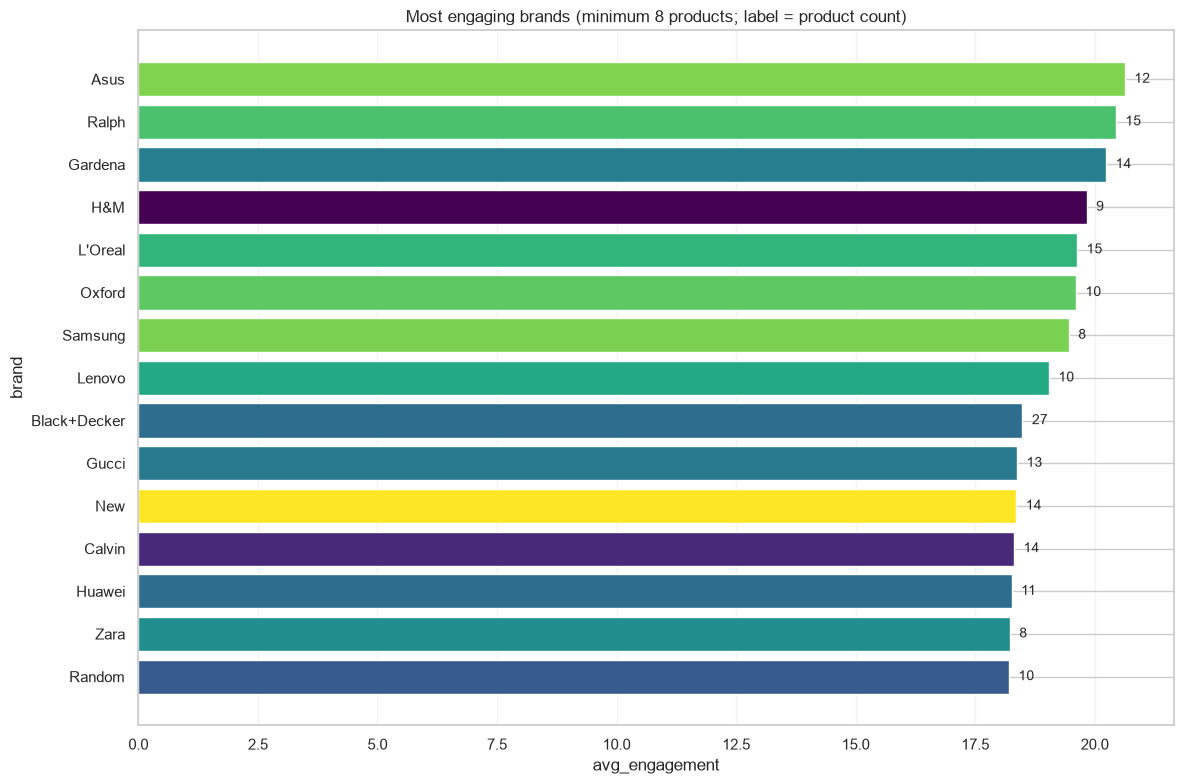

Commercial readout:
- noon shows the highest discounted share at 31.5%.
- Beauty has the highest average rating at 3.84.
- Asus leads the brand engagement ranking with an average engagement score of 20.63.
- The price-vs-rating view should be read within each currency panel, not across currencies.


In [13]:
commercial = run_commercial(eda_df)
eda_df = commercial["eda_df"]

display(Markdown("### Source-level commercial summary"))
display(commercial["source_summary"])

plot_price_vs_rating(eda_df)
plot_discount_penetration(commercial["discount_penetration"])
plot_brand_engagement(commercial["brand_rank"])
print(commercial["readout"])

In [14]:
launch_dashboard(eda_df)

HTML(value='\n<style>\n.slice-kpi-grid { display:grid; grid-template-columns:repeat(3, minmax(180px, 1fr)); ga…

Button(button_style='warning', description='Clear slicers', icon='refresh', layout=Layout(height='38px', width…

HTML(value='')

HTML(value='')

HTML(value='')

Output()

HTML(value='')

{'filters': {'source': Dropdown(description='Source:', layout=Layout(width='23%'), options=('All', 'aliexpress', 'amazon', 'ebay', 'jumia', 'noon'), value='All'),
  'category': Dropdown(description='Category:', layout=Layout(width='23%'), options=('All', 'Automotive', 'Beauty', 'Books', 'Electronics', 'Fashion', 'Food', 'Garden', 'Home', 'Sports', 'Toys'), value='All'),
  'currency': Dropdown(description='Currency:', layout=Layout(width='23%'), options=('All', 'AED', 'EGP', 'USD'), value='All'),
  'availability': Dropdown(description='Avail:', layout=Layout(width='23%'), options=('All', 'in_stock', 'limited', 'out_of_stock'), value='All'),
  'price_tier': Dropdown(description='Price tier:', layout=Layout(width='17%'), options=('All', 'Budget', 'Mid-range', 'Premium', 'Luxury'), value='All')},
 'group': Dropdown(description='Group by:', layout=Layout(width='17%'), options=('brand', 'category', 'source', 'availability', 'price_tier_within_currency'), value='brand'),
 'metric': Dropdown(d

### Silhouette search

,k,silhouette_score
0,2,0.2169
1,3,0.1928
2,4,0.1529
3,5,0.1649
4,6,0.1858


### Cluster profile

,cluster,products,median_price,avg_discount,avg_rating,avg_reviews,in_stock_share,dominant_category,dominant_source
0,0,834,1784.1,5.40,3.77,253.99,100.0,Beauty,noon
1,1,166,1538.1,5.27,3.79,322.56,0.0,Beauty,ebay


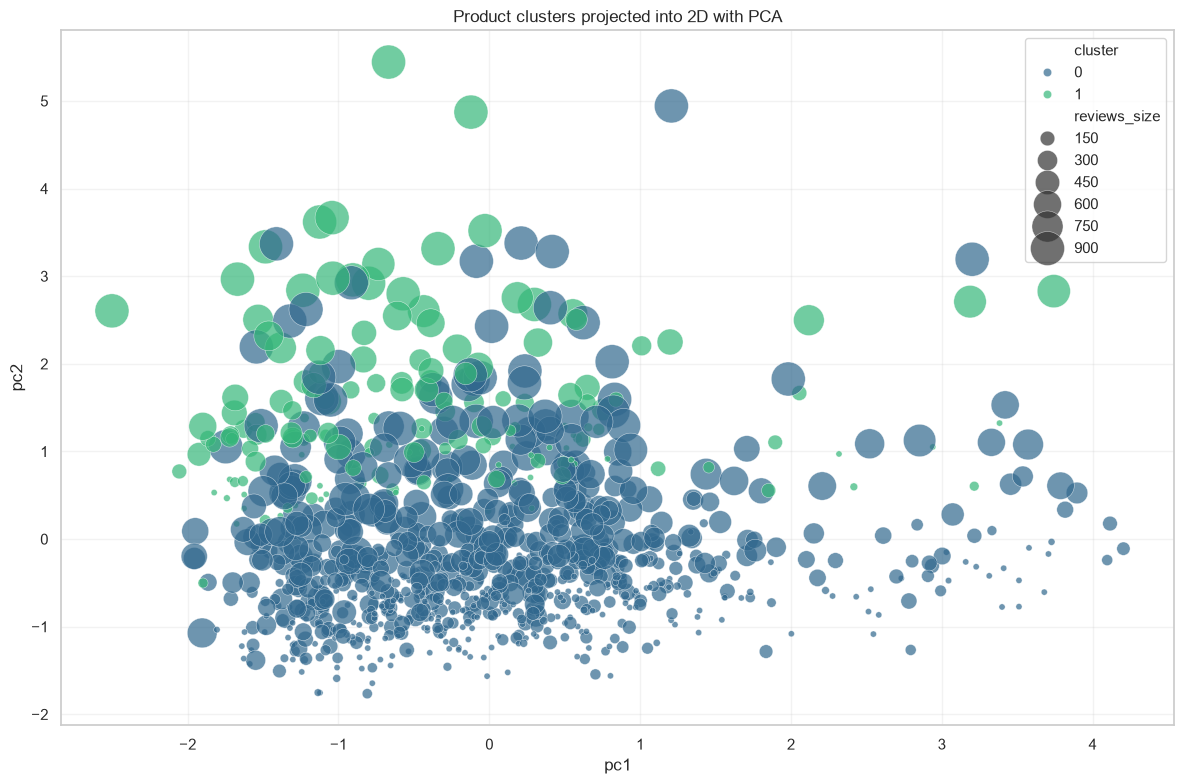

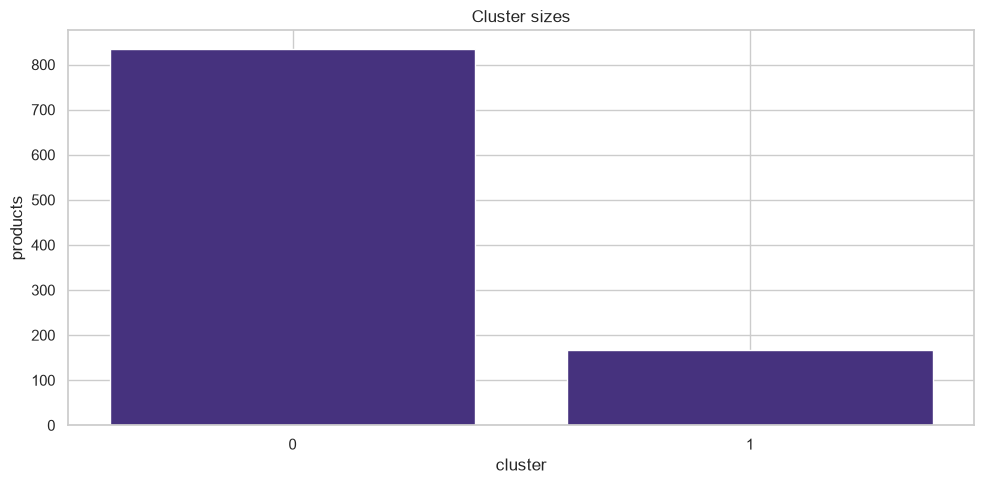

Segmentation readout:
- Cluster 0 is the largest segment with 834 products.
- Cluster 1 has the highest average rating at 3.79.
- Use the cluster profile table to describe segments by price level, discount intensity, review volume, and dominant category/source mix.


In [15]:
eda_df, cluster_profile, silhouette_df = run_segmentation(eda_df, return_artifacts=True)

display(Markdown("### Silhouette search"))
display(silhouette_df)
display(Markdown("### Cluster profile"))
display(cluster_profile)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=eda_df, x="pc1", y="pc2", hue="cluster",
                size="reviews_size", sizes=(20, 600), alpha=0.7, palette="viridis")
plt.title("Product clusters projected into 2D with PCA")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(cluster_profile["cluster"], cluster_profile["products"])
plt.title("Cluster sizes")
plt.xlabel("cluster")
plt.ylabel("products")
plt.tight_layout()
plt.show()

print(segmentation_readout(cluster_profile))

### Anomaly summary by source

,source,products,anomalies,anomaly_share_pct,avg_price,avg_rating
0,jumia,200,34,17.0,24387.20,3.72
1,aliexpress,200,5,2.5,241.43,3.79
2,ebay,200,4,2.0,1556.47,3.72
3,noon,200,4,2.0,3866.18,3.78
4,amazon,200,3,1.5,1292.70,3.83


### Top anomalous products

,title,brand,source,category,currency,price_current,discount_pct_filled,rating_score_imputed,reviews_count,availability,anomaly_score
0,Gucci Elite Wallet Plus,Gucci,jumia,Fashion,EGP,47231.87,30.1,3.1,858,limited,0.0840
1,HarperCollins High Performance Reference Manual Plus,HarperCollins,aliexpress,Books,USD,34.68,7.4,2.9,689,in_stock,0.0719
2,Adidas Hoodie 2024,Adidas,jumia,Fashion,EGP,45048.83,0.0,3.3,1506,in_stock,0.0655
3,IKEA Kettle Plus,IKEA,noon,Home,AED,7926.28,18.7,3.5,2316,in_stock,0.0593
4,Lenovo Router,Lenovo,jumia,Electronics,EGP,43061.65,0.0,4.5,600,in_stock,0.0559
5,Lay's Honey Max,Lay's,noon,Food,AED,6198.36,0.0,5.0,1372,in_stock,0.0549
6,Shell Wireless Dash Camera v2,Shell,jumia,Automotive,EGP,24602.50,28.1,2.5,127,in_stock,0.0491
7,Mobil Wireless Tool Kit v2,Mobil,jumia,Automotive,EGP,44518.55,30.6,4.6,367,in_stock,0.0481
8,Mobil Portable Tyre Inflator 2024,Mobil,jumia,Automotive,EGP,40546.13,25.9,3.5,819,in_stock,0.0480
9,Under Armour Advanced Cycling Helmet Pro,Under,jumia,Sports,EGP,44277.48,15.3,4.8,110,in_stock,0.0416


### Hidden-gem candidates

,title,brand,source,category,currency,price_current,rating_score_imputed,reviews_count,discount_pct_filled,price_tier_within_currency,engagement_score
0,Tefal High Performance Rug Max,Tefal,noon,Home,AED,1883.31,5.0,5,18.0,Mid-range,8.958797
1,McGraw-Hill Deluxe Masterclass,McGraw-Hill,amazon,Books,USD,948.02,5.0,9,0.0,Premium,11.512925
2,Kellogg's Granola Max,Kellogg's,aliexpress,Food,USD,84.87,5.0,37,0.0,Budget,18.187931
3,Charlotte Tilbury Perfume Plus,Charlotte,amazon,Beauty,USD,1989.96,5.0,48,0.0,Luxury,19.459101
4,Barbie Elite Action Figure Max,Barbie,aliexpress,Toys,USD,406.06,5.0,70,0.0,Mid-range,21.313399
5,Bosch Soil Mix Lite,Bosch,aliexpress,Garden,USD,289.29,4.9,4,0.0,Mid-range,7.886246
6,Adidas Essential Water Bottle,Adidas,jumia,Sports,EGP,31292.31,4.9,21,0.0,Premium,15.146108
7,Unilever Classic Olive Oil 2024,Unilever,noon,Food,AED,1160.60,4.9,40,0.0,Budget,18.196503
8,Reebok Compact Dumbbell Set Lite,Reebok,jumia,Sports,EGP,17206.31,4.9,43,0.0,Mid-range,18.542529
9,Shell Deluxe Dash Camera,Shell,jumia,Automotive,EGP,49482.73,4.8,18,0.0,Luxury,14.133307


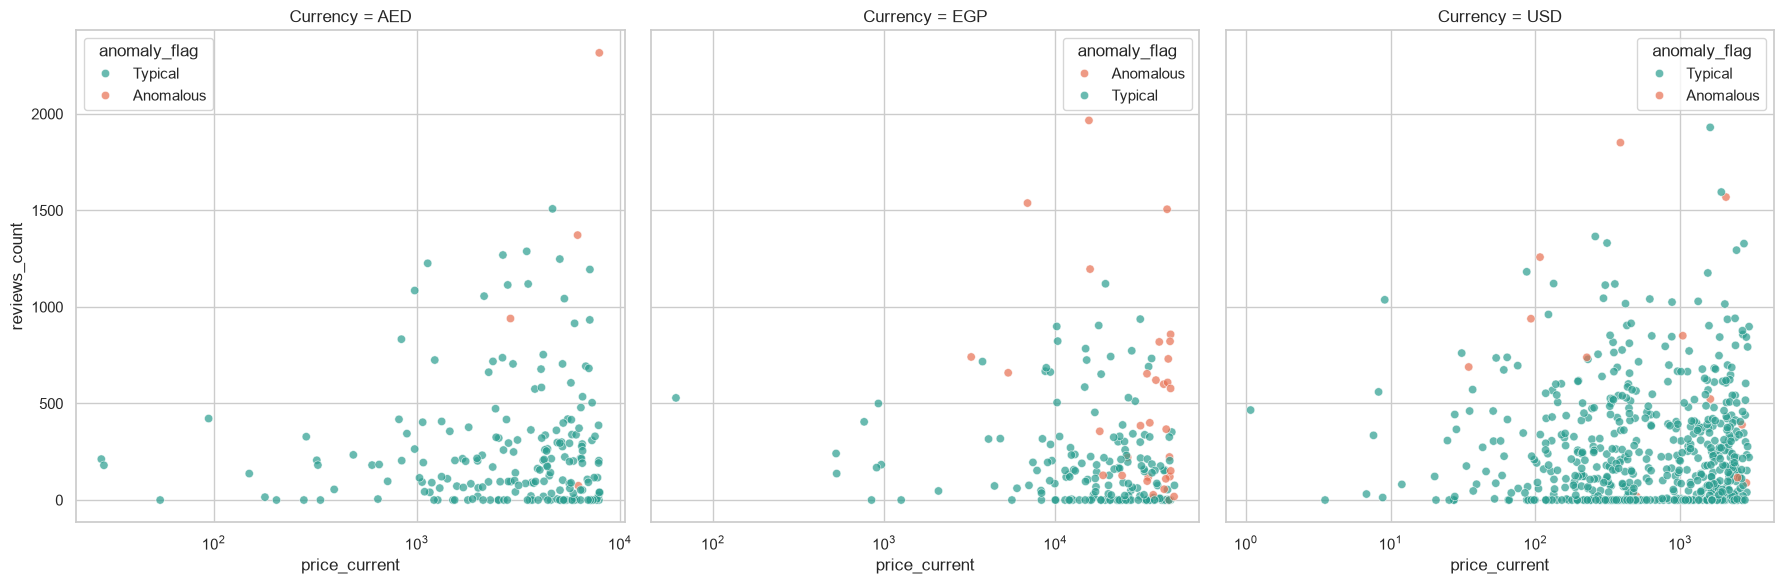

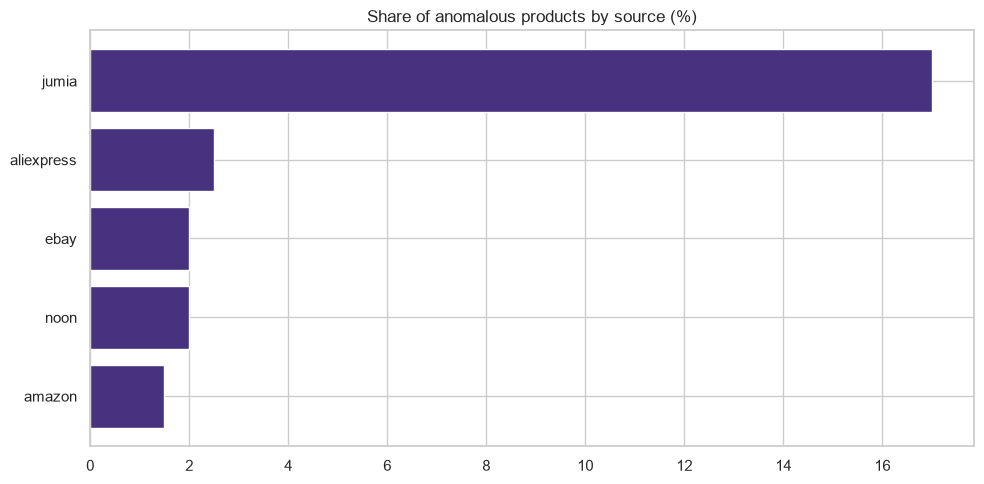

Anomaly readout:
- The model flagged 50 products as unusual out of 1000 total rows.
- The strict hidden-gem filter uses rating >= 4.50 and reviews <= 76.
- Use the anomaly table for audit-style inspection and the hidden-gem table for discovery-style storytelling.


In [16]:
eda_df, anomaly_summary, top_anomalies, hidden_gems = run_anomaly(eda_df)

display(Markdown("### Anomaly summary by source"))
display(anomaly_summary)
display(Markdown("### Top anomalous products"))
display(top_anomalies)
display(Markdown("### Hidden-gem candidates"))
display(hidden_gems)

palette = {"Typical": "#2a9d8f", "Anomalous": "#e76f51"}
currencies = sorted(eda_df["currency"].dropna().unique())
fig, axes = plt.subplots(1, len(currencies), figsize=(6 * len(currencies), 6), sharey=True)
if len(currencies) == 1:
    axes = [axes]
for ax, cur in zip(axes, currencies):
    sns.scatterplot(data=eda_df[eda_df["currency"] == cur], x="price_current",
                    y="reviews_count", hue="anomaly_flag", palette=palette,
                    alpha=0.7, ax=ax)
    ax.set_xscale("log")
    ax.set_title(f"Currency = {cur}")
plt.tight_layout()
plt.show()

share = anomaly_summary.sort_values("anomaly_share_pct")
plt.figure(figsize=(10, 5))
plt.barh(share["source"], share["anomaly_share_pct"])
plt.title("Share of anomalous products by source (%)")
plt.tight_layout()
plt.show()

print(anomaly_readout(eda_df))

### Model performance

,metric,value
0,Review cutoff,385.000
1,Positive class share %,25.100
2,ROC AUC,0.592
3,Accuracy,0.616
4,Precision,0.306
5,Recall,0.413


### Breakout-potential products

,title,brand,source,category,currency,price_current,rating_score_imputed,reviews_count,discount_pct_filled,availability,price_tier_within_currency,high_review_propensity
0,Cadbury Advanced Granola v2,Cadbury,aliexpress,Food,USD,329.10,2.9,77,0.0,in_stock,Mid-range,0.633
1,Calvin Klein T-Shirt Plus,Calvin,ebay,Fashion,USD,2372.62,2.6,193,0.0,in_stock,Luxury,0.621
2,Tommy Hilfiger Hoodie,Tommy,aliexpress,Fashion,USD,340.44,2.8,265,0.0,in_stock,Mid-range,0.618
3,Barbie Wireless Doll Lite,Barbie,aliexpress,Toys,USD,385.22,2.6,196,0.0,in_stock,Mid-range,0.604
4,Calvin Klein Sneakers Pro,Calvin,amazon,Fashion,USD,1357.13,3.9,379,0.0,out_of_stock,Premium,0.600
5,Samsung Power Bank Plus,Samsung,aliexpress,Electronics,USD,318.18,3.5,96,0.0,in_stock,Mid-range,0.595
6,Tefal Iron Pro,Tefal,aliexpress,Home,USD,271.41,4.3,21,0.0,in_stock,Mid-range,0.594
7,Samsung Lightweight Speaker 2024,Samsung,ebay,Electronics,USD,362.25,4.4,189,0.0,in_stock,Mid-range,0.592
8,Cadbury Multivitamin Lite,Cadbury,ebay,Food,USD,52.31,3.2,6,0.0,in_stock,Budget,0.591
9,Calvin Klein Professional T-Shirt Pro,Calvin,jumia,Fashion,EGP,39683.12,2.7,75,0.0,in_stock,Luxury,0.590


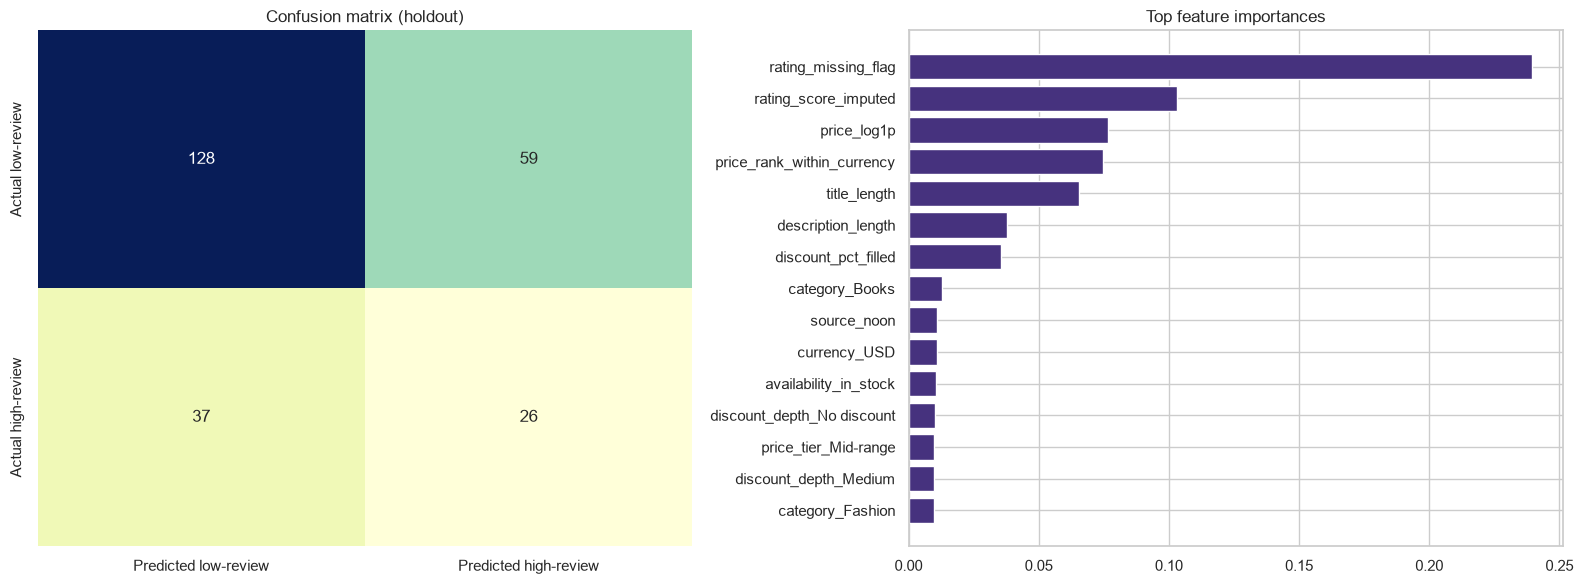

In [17]:
eda_df, metrics_df, breakout, art = run_propensity(eda_df, return_artifacts=True)

display(Markdown("### Model performance"))
display(metrics_df)
display(Markdown("### Breakout-potential products"))
display(breakout)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(art["confusion_matrix"], annot=True, fmt="d", cmap="YlGnBu",
            cbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (holdout)")
imp = art["importance"]
axes[1].barh(imp["feature"], imp["importance"])
axes[1].set_title("Top feature importances")
plt.tight_layout()
plt.show()

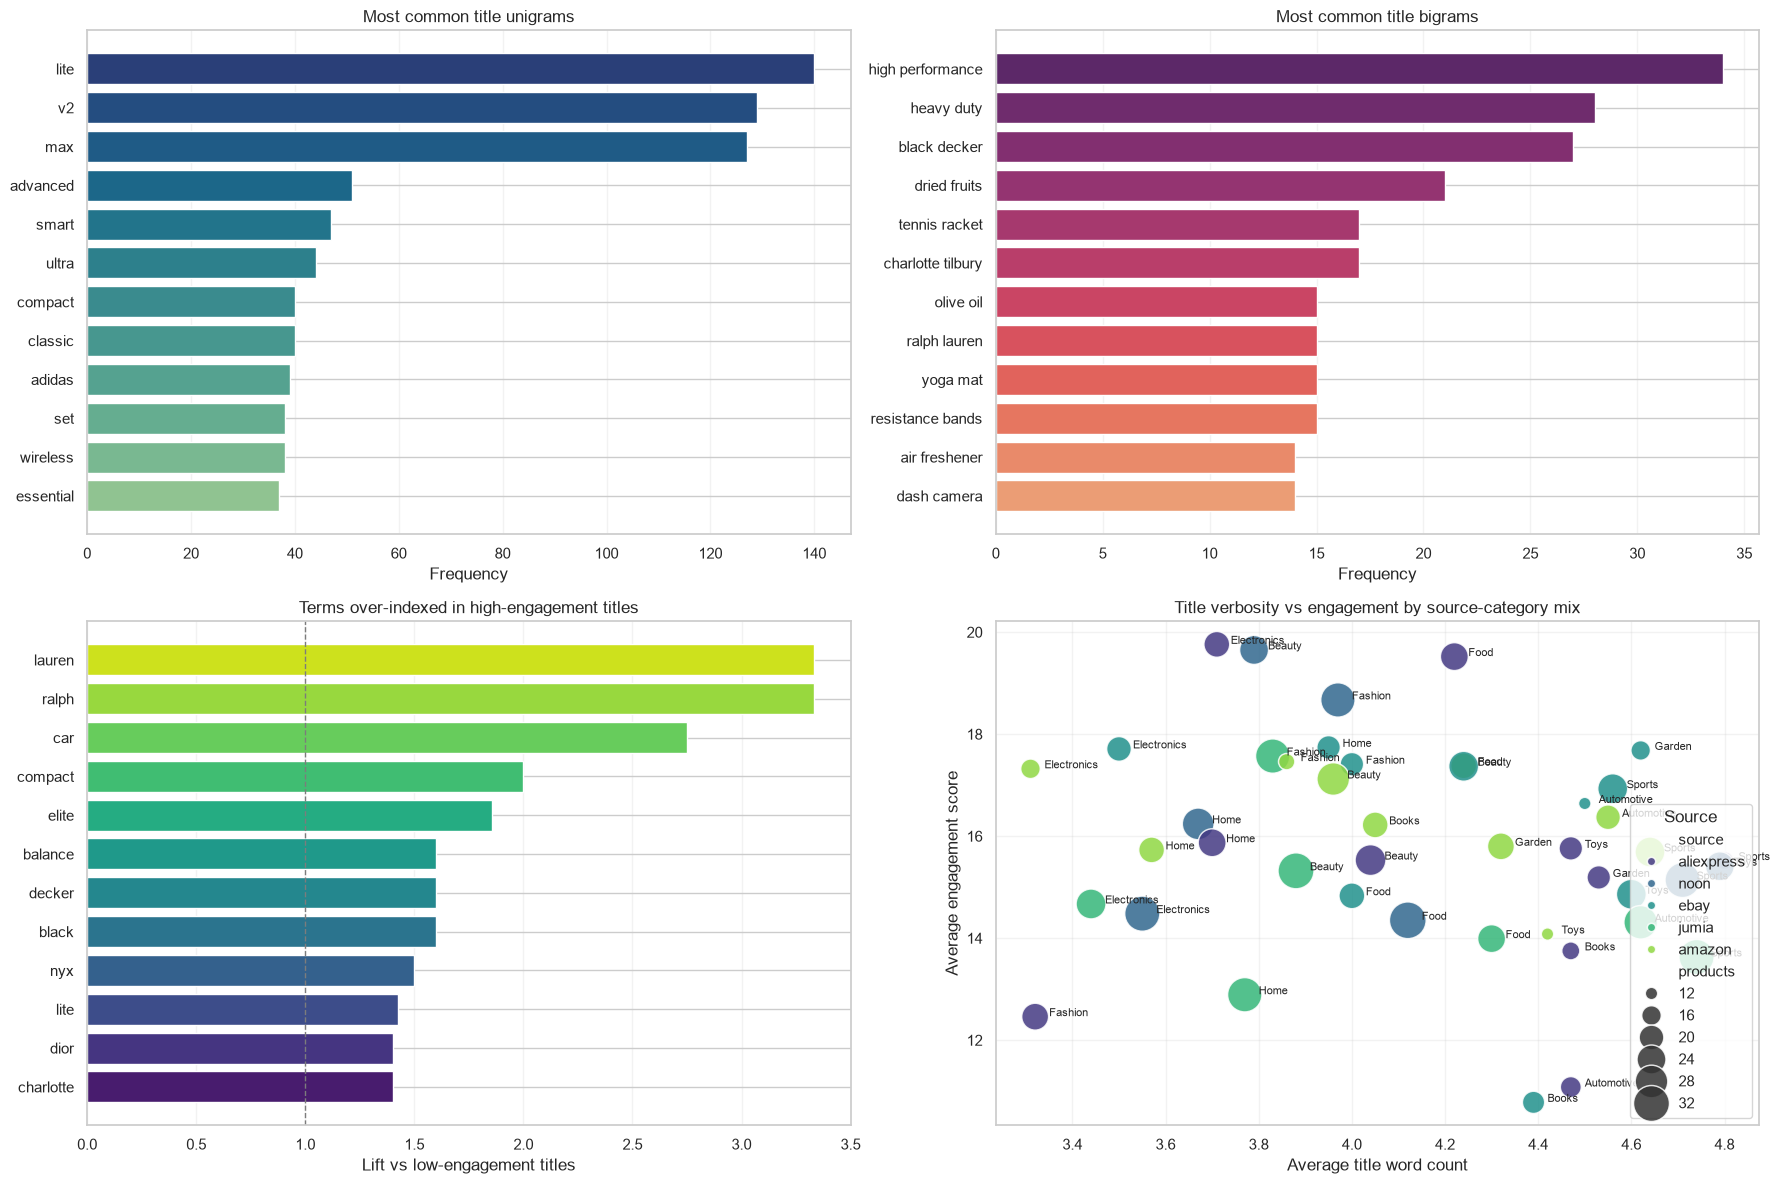

### Source-category copy style summary

,source,category,products,avg_title_words,avg_desc_length,avg_engagement
0,aliexpress,Electronics,21,3.71,74.19,19.76
1,noon,Beauty,24,3.79,74.58,19.65
2,aliexpress,Food,23,4.22,73.70,19.52
3,noon,Fashion,30,3.97,75.43,18.67
4,ebay,Home,19,3.95,73.89,17.74
5,ebay,Electronics,20,3.50,75.25,17.71
6,ebay,Garden,16,4.62,72.62,17.68
7,jumia,Fashion,30,3.83,74.60,17.57
8,amazon,Fashion,14,3.86,75.36,17.46
9,ebay,Fashion,19,4.00,72.95,17.41


Text-signal readout:
- The most repeated qualifying phrase is `high performance` with 34 mentions.
- `lauren` is the strongest high-engagement title signal in this run, with lift 3.33.
- Use the style summary to compare whether shorter or longer product titles appear to correlate with stronger engagement in each marketplace-category pocket.


In [18]:
text_res = run_text_signals(eda_df)
plot_text_signals(text_res)
display(Markdown("### Source-category copy style summary"))
display(text_res["style_summary"].head(20))
print(text_res["readout"])

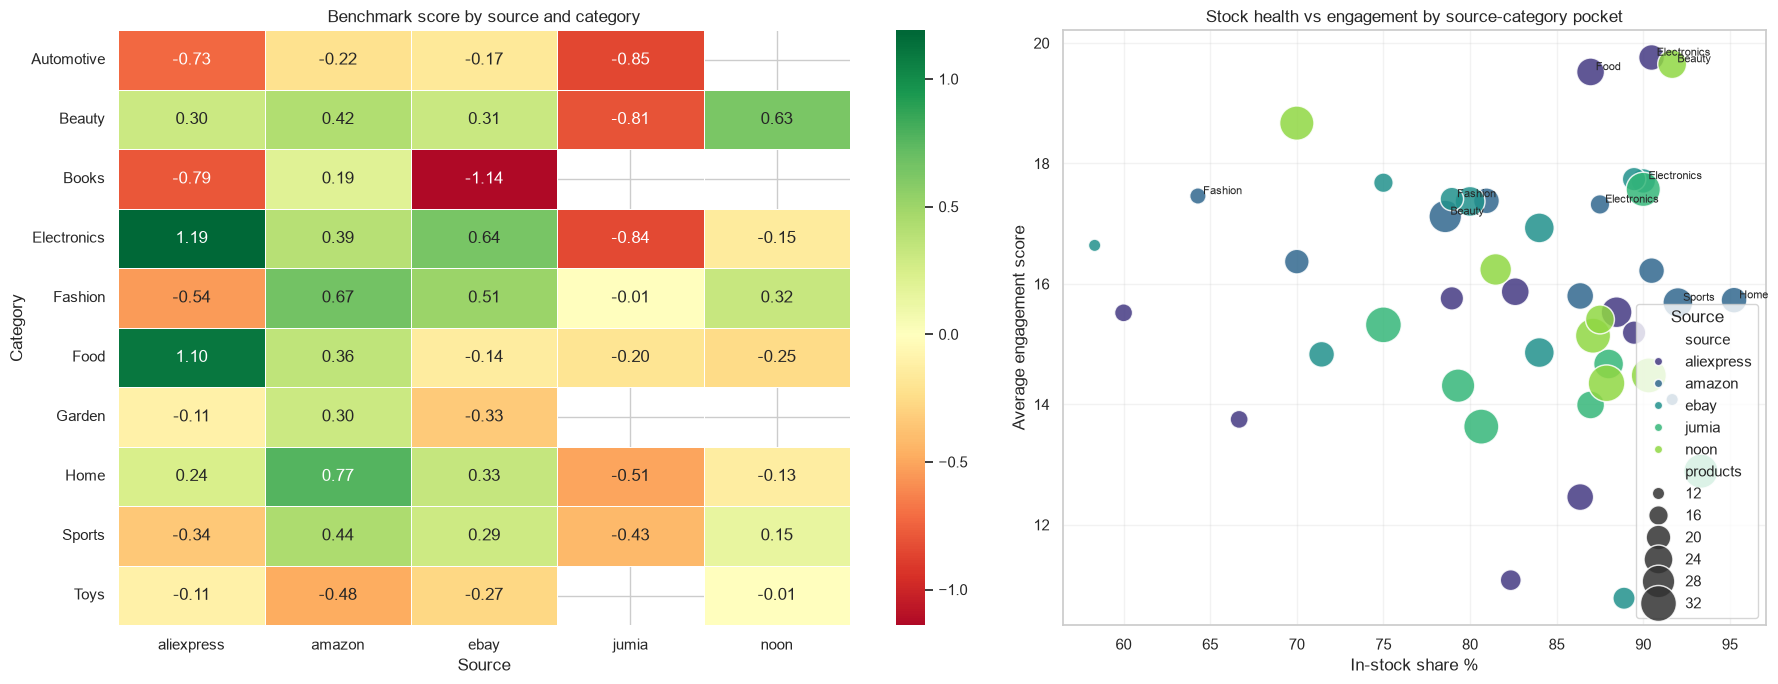

### Strongest pockets

,source,category,products,median_price,avg_rating,avg_reviews,avg_discount,avg_engagement,in_stock_share,anomaly_share,avg_review_propensity,benchmark_score
0,aliexpress,Electronics,21,198.67,3.83,426.86,8.26,19.76,90.48,9.52,0.57,1.19
1,aliexpress,Food,23,208.11,3.85,308.26,5.40,19.52,86.96,0.00,0.53,1.10
2,amazon,Home,21,1155.22,3.92,274.00,6.12,15.73,95.24,0.00,0.46,0.77
3,amazon,Fashion,14,1024.98,4.19,282.64,6.66,17.46,64.29,0.00,0.42,0.67
4,ebay,Electronics,20,1450.12,3.86,287.00,2.76,17.71,90.00,0.00,0.46,0.64
5,noon,Beauty,24,4382.72,3.78,299.25,3.94,19.65,91.67,0.00,0.39,0.63
6,ebay,Fashion,19,1748.22,3.73,295.05,8.79,17.41,78.95,0.00,0.49,0.51
7,amazon,Sports,25,1136.65,3.86,230.44,5.04,15.69,92.00,0.00,0.43,0.44
8,amazon,Beauty,28,1001.92,3.87,259.29,6.07,17.12,78.57,0.00,0.44,0.42
9,amazon,Electronics,16,1420.14,3.84,171.56,0.92,17.32,87.50,0.00,0.45,0.39


### Weakest pockets

,source,category,products,median_price,avg_rating,avg_reviews,avg_discount,avg_engagement,in_stock_share,anomaly_share,avg_review_propensity,benchmark_score
0,ebay,Books,18,1115.89,3.63,149.17,4.19,10.78,88.89,5.56,0.30,-1.14
1,jumia,Automotive,29,26081.59,3.74,229.86,5.93,14.31,79.31,24.14,0.38,-0.85
2,jumia,Electronics,25,20688.83,3.49,239.36,5.96,14.67,88.00,20.00,0.41,-0.84
3,jumia,Beauty,32,25998.54,3.78,259.38,5.66,15.32,75.00,25.00,0.37,-0.81
4,aliexpress,Books,15,325.12,3.71,242.40,6.37,13.75,66.67,6.67,0.39,-0.79
5,aliexpress,Automotive,17,358.34,3.65,157.94,6.36,11.08,82.35,0.00,0.40,-0.73
6,aliexpress,Fashion,22,242.96,3.58,264.64,3.50,12.46,86.36,0.00,0.46,-0.54
7,jumia,Home,30,24450.92,3.66,146.20,5.18,12.89,93.33,3.33,0.34,-0.51
8,amazon,Toys,12,1891.89,3.42,208.67,6.56,14.08,91.67,0.00,0.41,-0.48
9,jumia,Sports,31,18514.54,3.85,275.48,7.50,13.63,80.65,12.90,0.36,-0.43


Benchmark readout:
- The strongest source-category pocket is `aliexpress | Electronics` with benchmark score 1.19.
- The weakest pocket is `ebay | Books` with score -1.14.
- Use the heatmap to compare pockets structurally, and use the scatter to spot combinations with healthy stock but weak engagement or vice versa.


In [19]:
bench = run_benchmark(eda_df)
plot_benchmark(bench)
display(Markdown("### Strongest pockets"))
display(bench["strongest"])
display(Markdown("### Weakest pockets"))
display(bench["weakest"])
print(bench["readout"])

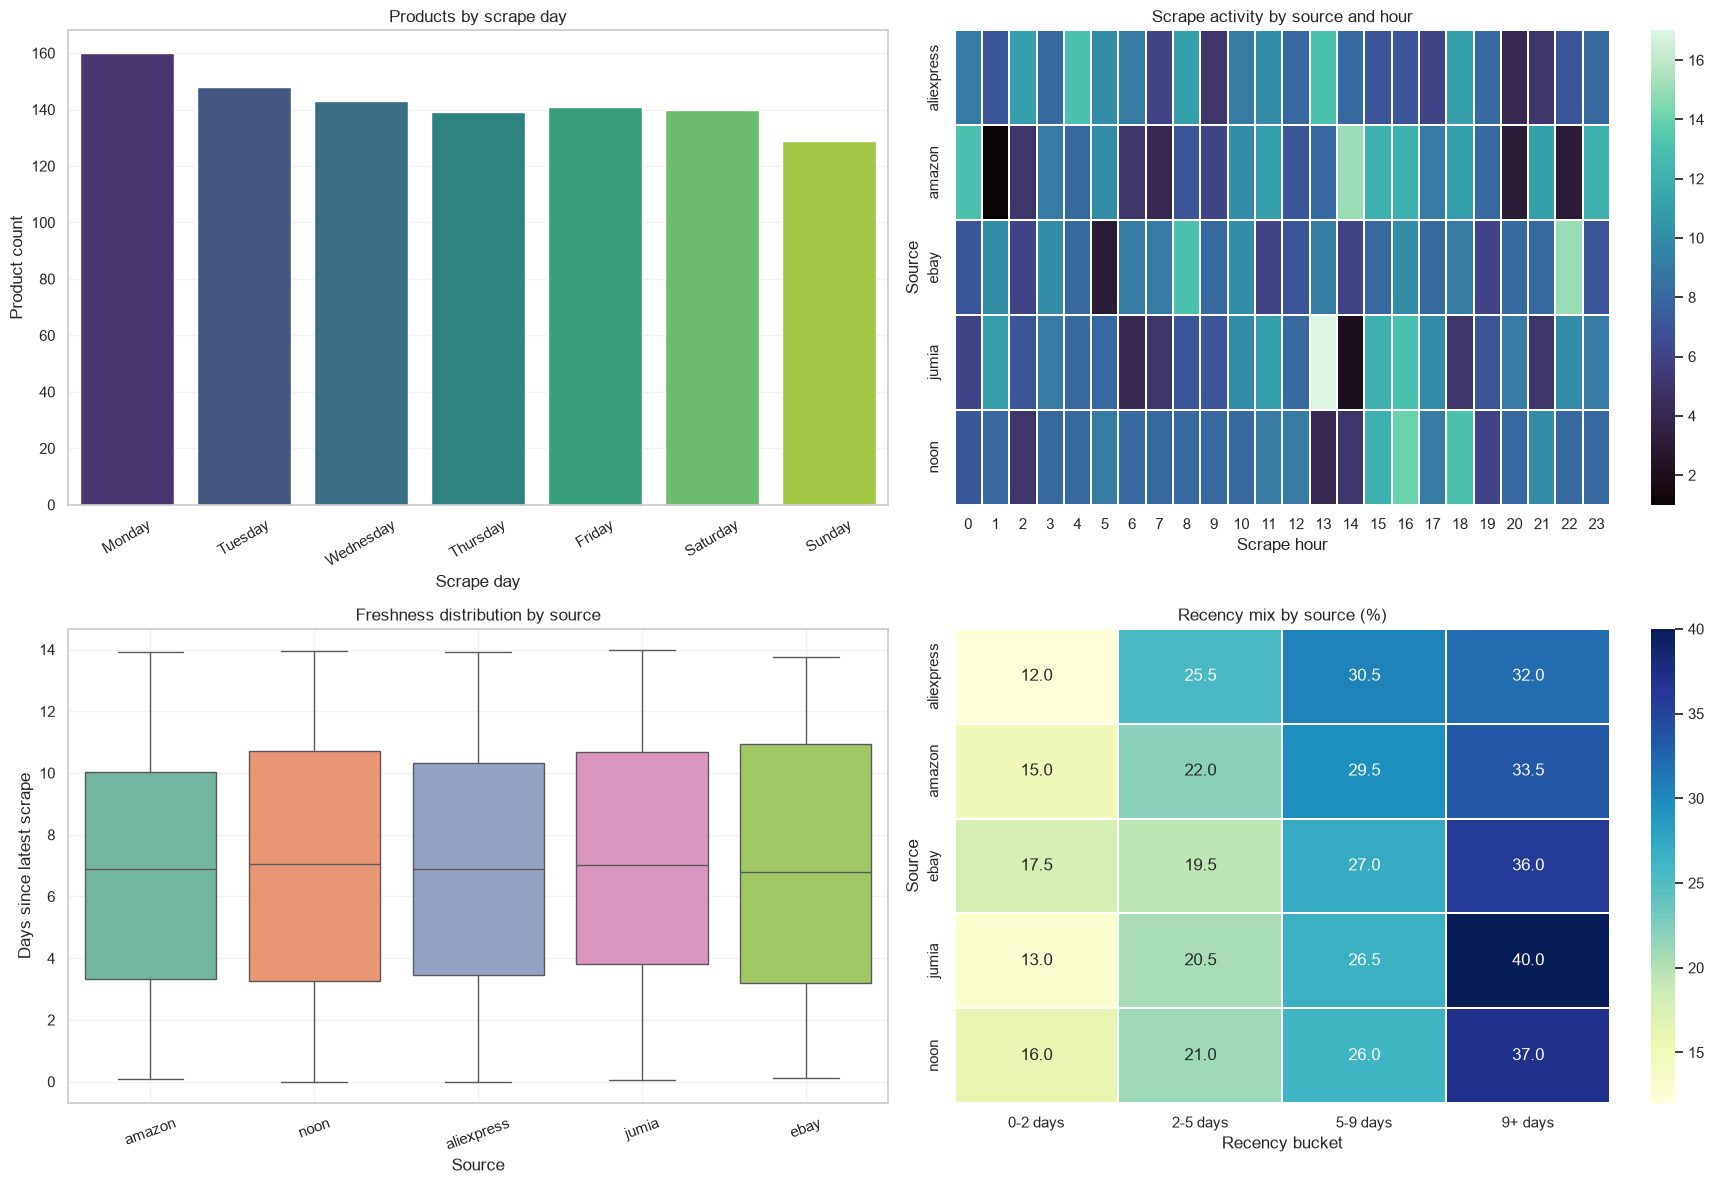

,source,products,oldest_scrape,latest_scrape,avg_days_from_latest,median_days_from_latest
0,aliexpress,200,2026-03-14 13:23:34.673785,2026-03-28 11:32:46.870102,6.88,6.89
1,amazon,200,2026-03-14 13:34:53.405460,2026-03-28 09:29:04.809815,6.88,6.89
2,noon,200,2026-03-14 12:52:59.456187,2026-03-28 11:34:18.894356,6.94,7.05
3,ebay,200,2026-03-14 17:19:22.269246,2026-03-28 08:56:32.861165,6.98,6.79
4,jumia,200,2026-03-14 12:10:39.168178,2026-03-28 10:06:19.974735,7.25,7.03


Freshness readout:
- `aliexpress` has the freshest average capture window at 6.88 days from the latest scrape.
- `jumia` is the stalest on average at 7.25 days.
- Use the hour heatmap and recency mix to decide whether observed marketplace differences may partly reflect capture timing rather than pure catalog behavior.


In [20]:
fresh = run_freshness(eda_df)
plot_freshness(fresh)
if fresh["available"]:
    display(fresh["summary"])
print(fresh["readout"])

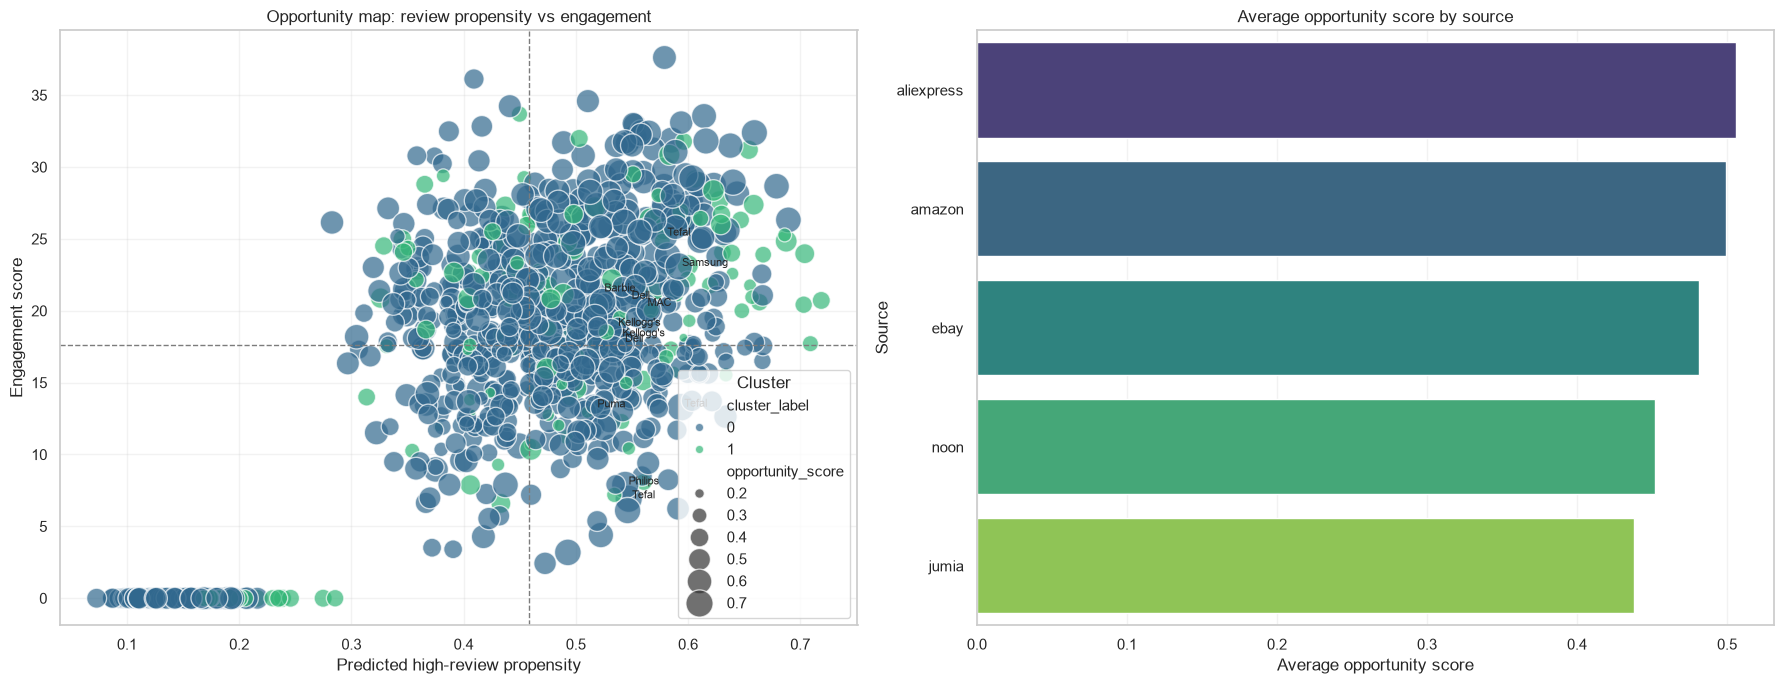

### Top strategic products

,title,brand,source,category,currency,price_current,rating_score_imputed,reviews_count,discount_pct_filled,high_review_propensity,anomaly_score,cluster_label,engagement_score,opportunity_score
0,Tefal Iron Pro,Tefal,aliexpress,Home,USD,271.41,4.3,21,0.0,0.593612,-0.1152,0,13.291483,0.7265
1,Barbie Elite Action Figure Max,Barbie,aliexpress,Toys,USD,406.06,5.0,70,0.0,0.522446,-0.1170,0,21.313399,0.7259
2,Dell Advanced Laptop 2024,Dell,aliexpress,Electronics,USD,37.27,4.6,47,26.5,0.540814,-0.0478,0,17.807525,0.7246
3,Kellogg's Ultra Protein Bar Max,Kellogg's,amazon,Food,USD,1518.89,4.5,66,0.0,0.534722,-0.1467,0,18.921117,0.7182
4,Kellogg's Granola Max,Kellogg's,aliexpress,Food,USD,84.87,5.0,37,0.0,0.538504,-0.0834,0,18.187931,0.7181
5,Tefal Portable Blender Plus,Tefal,ebay,Home,USD,586.28,4.7,212,0.0,0.578579,-0.1419,0,25.198073,0.7175
6,MAC Lightweight Mascara Plus,MAC,aliexpress,Beauty,USD,448.19,4.5,90,0.0,0.560883,-0.1291,0,20.298868,0.7147
7,Philips Fan Max,Philips,aliexpress,Home,USD,164.45,4.4,5,21.9,0.544037,-0.0298,0,7.883742,0.7095
8,Samsung Lightweight Speaker 2024,Samsung,ebay,Electronics,USD,362.25,4.4,189,0.0,0.591664,-0.1488,0,23.086906,0.7083
9,Dell Pro Projector Plus,Dell,aliexpress,Electronics,USD,103.44,4.6,91,0.0,0.546772,-0.1182,0,20.800227,0.7062


Opportunity readout:
- `aliexpress` has the highest average opportunity score at 0.506.
- The top product candidate in this scoring system is `Tefal Iron Pro` with score 0.727.
- This score favors strong ratings, breakout-like review propensity, low current review saturation, in-stock status, and lower anomaly risk.


In [21]:
opp = run_opportunity(eda_df)
plot_opportunity_map(opp)
display(Markdown("### Top strategic products"))
display(opp["strategic_products"])
print(opp["readout"])

In [22]:
summary_text = build_summary(eda_df, bench["benchmark_df"], opp["strategic_products"])
display(Markdown(summary_text))

### Headline Findings
- **Marketplace leader by engagement:** Amazon with average engagement score 16.37
- **Highest-rated category:** Beauty with average rating 3.84
- **Most review-rich brand:** Nike with 9,574 total reviews
- **Most anomaly-heavy source:** Jumia
- **Strongest source-category pocket:** Aliexpress | Electronics with benchmark score 1.19
- **Top strategic product candidate:** Tefal Iron Pro from Aliexpress
- **Best-rated segment:** Cluster 1 with average rating 3.79

### Strategic Priorities
- Prioritize in-stock, high-rating, under-reviewed products for visibility, merchandising, or promotion.
- Audit the highest-anomaly sources and source-category pockets first to catch pricing or catalog irregularities.
- Reuse wording patterns associated with high-engagement listings where they fit the category and marketplace context.
- Track benchmark-pocket movement across future scrapes to monitor improvement or deterioration over time.

### Project Notes
- The dataset is a scraped catalog snapshot rather than a transactional sales dataset.
- Review volume reflects public social proof and should not be treated as a direct sales measure.
- The clustering, anomaly detection, and propensity modeling layers are exploratory decision-support tools.

In [23]:
manifest = export_all(
    eda_df=eda_df,
    benchmark_df=bench["benchmark_df"],
    strategic_products=opp["strategic_products"],
    export_dir=EXPORT_DIR,
    summary_text=summary_text,
)
display(manifest)

,file,rows,path
0,benchmark_matrix.csv,44,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\benchmark_matrix.csv
1,top_anomalies.csv,50,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\top_anomalies.csv
2,hidden_gems.csv,32,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\hidden_gems.csv
3,breakout_candidates.csv,10,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\breakout_candidates.csv
4,strategic_products.csv,25,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\strategic_products.csv
5,executive_summary.txt,26,D:\projects\ravi praksh projects\ecommerce-analysis\outputs\executive_summary.txt
